In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = "../../CSVs/Bangladesh_2018_NSRDB_986494_OneAxis.csv"

df = pd.read_csv(
    path,
    skiprows=2,
    low_memory=False
)

print(df.shape)
display(df.head())

(8760, 2034)


,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,...,3.9550 um,3.9600 um,3.9650 um,3.9700 um,3.9750 um,3.9800 um,3.9850 um,3.9900 um,3.9950 um,4.0000 um
0,2018,1,1,0,0,14.2,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2018,1,1,1,0,15.9,16.0,91.0,21.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2018,1,1,2,0,17.7,81.0,449.0,193.0,1.0,...,5.264890,5.393690,5.518221,5.358967,5.062947,4.930521,5.034317,4.918242,4.711062,4.541866
3,2018,1,1,3,0,20.8,114.0,641.0,387.0,1.0,...,5.744575,5.817869,5.895465,5.776573,5.579923,5.481010,5.530419,5.440538,5.289392,5.171529
4,2018,1,1,4,0,23.0,134.0,738.0,547.0,0.0,...,5.662460,5.711034,5.768289,5.669485,5.519186,5.437749,5.464392,5.388048,5.266649,5.173240


Dataset shape: (8760, 2034)
Duplicate rows: 0

Column audit:


,dtype,non_null,missing,missing_pct,unique
Panel Azimuth Angle,float64,4424,4336,49.5,244
Panel Tilt,float64,4424,4336,49.5,4424
2.0200 um,float64,8751,9,0.1,4168
2.0150 um,float64,8751,9,0.1,4168
2.0000 um,float64,8751,9,0.1,4168
...,...,...,...,...,...
1.0030 um,float64,8760,0,0.0,4177
1.0040 um,float64,8760,0,0.0,4177
1.0050 um,float64,8760,0,0.0,4177
Temperature,float64,8760,0,0.0,278



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
1.0360 um,8760.0,188.834232,243.425408,-2503.656006,0.00000,0.000000,462.682558,840.914837
Clearsky DNI,8760.0,229.906963,282.947927,0.000000,0.00000,2.000000,486.000000,900.000000
Day,8760.0,15.720548,8.796749,1.000000,8.00000,16.000000,23.000000,31.000000
Hour,8760.0,11.500000,6.922582,0.000000,5.75000,11.500000,17.250000,23.000000
Minute,8760.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2.0200 um,8751.0,9.895075,15.510009,-37.815703,0.00000,0.000000,17.689981,55.999535
2.0250 um,8751.0,17.353320,26.286018,-430.507452,0.00000,0.000000,37.289458,102.035720
2.0300 um,8751.0,19.270957,31.014503,-978.009763,0.00000,0.000000,42.555896,180.563446
Panel Azimuth Angle,4424.0,179.674502,90.009587,89.998835,90.00000,90.000000,270.000000,270.001613



Most complete numeric signals:


,dtype,non_null,missing,missing_pct,unique
Year,int64,8760,0,0.0,1
Month,int64,8760,0,0.0,12
Day,int64,8760,0,0.0,31
Hour,int64,8760,0,0.0,24
Minute,int64,8760,0,0.0,1
Temperature,float64,8760,0,0.0,278
Clearsky DHI,float64,8760,0,0.0,462
Clearsky DNI,float64,8760,0,0.0,868
Clearsky GHI,float64,8760,0,0.0,955
Cloud Type,float64,8760,0,0.0,9


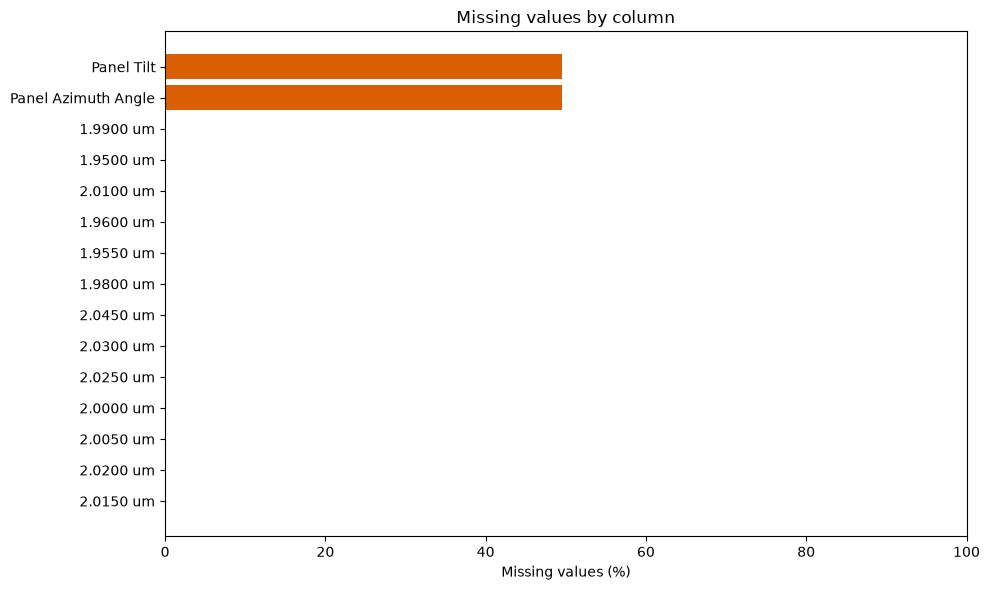

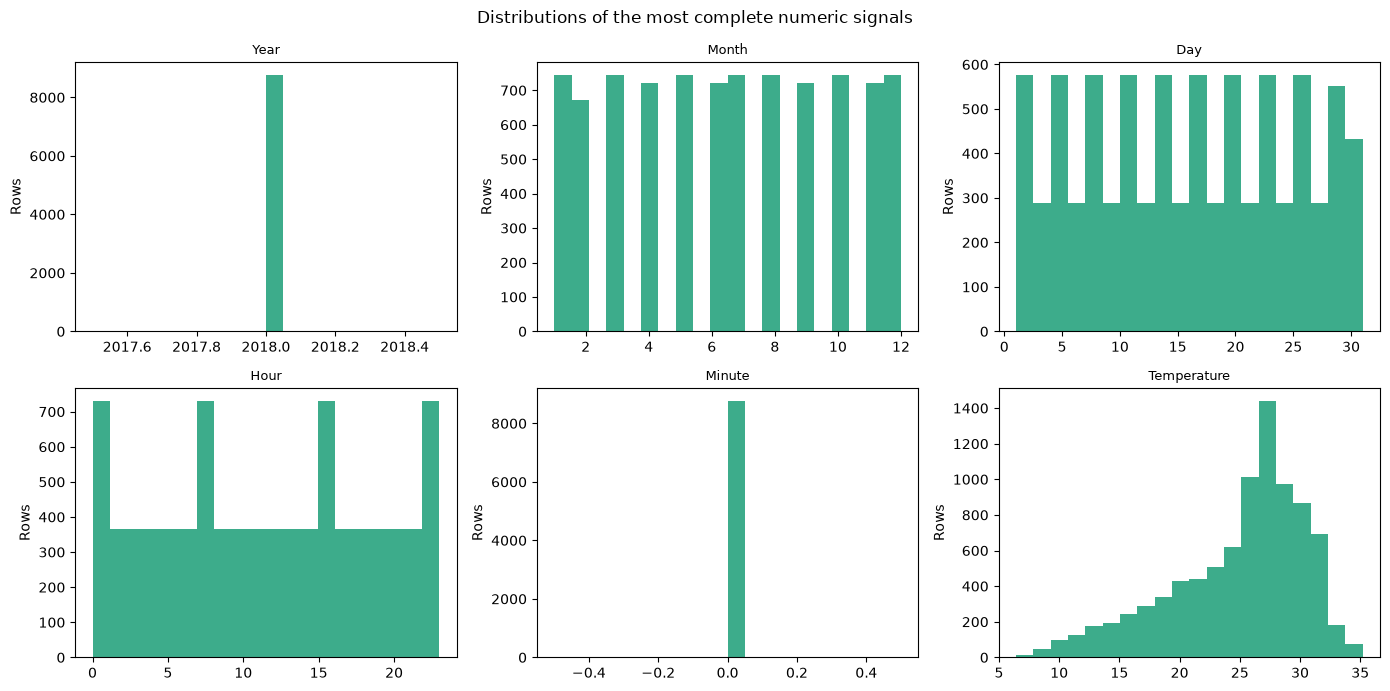


Relevant field summary:


,count,mean,std,min,25%,50%,75%,max
Temperature,8760.0,24.869589,5.553051,6.40,21.600,26.40,28.80,35.20
Pressure,8760.0,1006.099429,6.131307,987.00,1001.000,1007.00,1011.00,1019.00
GHI,8760.0,204.626256,279.229938,0.00,0.000,3.50,414.00,946.00
DNI,8760.0,150.272603,221.292982,0.00,0.000,0.00,288.00,900.00
DHI,8760.0,107.026142,142.612618,0.00,0.000,3.50,210.00,524.00
Clearsky GHI,8760.0,248.828995,322.027527,0.00,0.000,4.00,527.25,989.00
Clearsky DNI,8760.0,229.906963,282.947927,0.00,0.000,2.00,486.00,900.00
Clearsky DHI,8760.0,92.943721,119.455801,0.00,0.000,4.00,172.00,529.00
Relative Humidity,8760.0,80.241818,17.838749,20.03,69.115,84.03,95.81,100.00
Wind Speed,8760.0,1.726986,0.880158,0.10,1.100,1.50,2.20,7.50


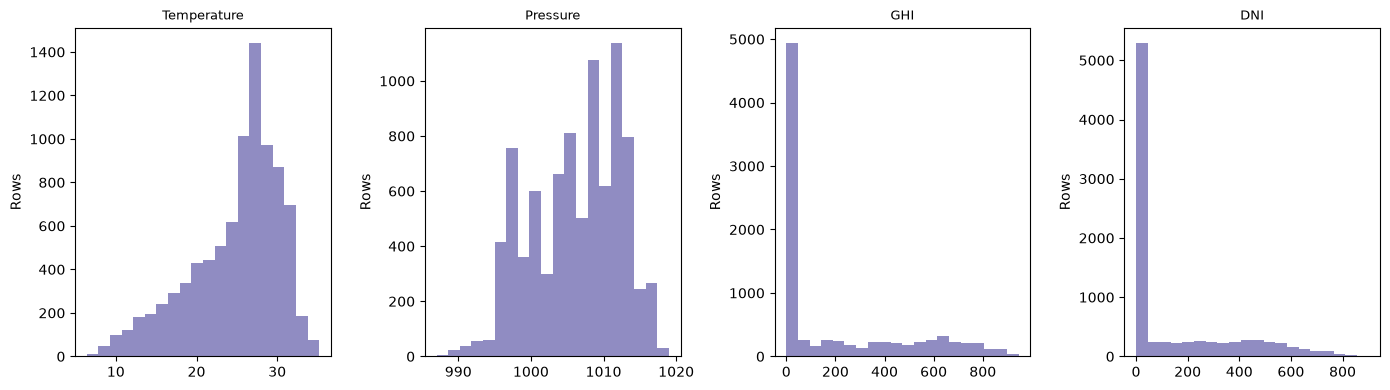

In [3]:
# Keep the dataset context explicit: this file is a single-location NSRDB summary, not a timestamped time series.
print("Dataset shape:", df.shape)
print("Duplicate rows:", f"{df.duplicated().sum():,}")

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique": df.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

print("\nColumn audit:")
display(audit)

numeric_cols = df.select_dtypes(include="number").columns.tolist()
if numeric_cols:
    complete_numeric = audit.loc[numeric_cols].sort_values(
        ["missing_pct", "non_null"], ascending=[True, False]
    )
    print("\nNumeric summary:")
    display(df[numeric_cols].describe().T.sort_values("count", ascending=False))
    print("\nMost complete numeric signals:")
    display(complete_numeric.head(10))
else:
    print("\nNo numeric columns found.")

# Plot the 15 columns with the most missing values.
missing_plot = audit.head(min(15, len(audit))).sort_values("missing_pct")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing_plot.index, missing_plot["missing_pct"], color="#d95f02")
ax.set_title("Missing values by column")
ax.set_xlabel("Missing values (%)")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

# Plot histograms for the six most complete numeric series.
if numeric_cols:
    plot_cols = complete_numeric.head(6).index.tolist()
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for axis, col in zip(axes.flat, plot_cols):
        values = pd.to_numeric(df[col], errors="coerce").dropna()
        if values.empty:
            axis.set_visible(False)
            continue
        axis.hist(values, bins=20, color="#1b9e77", alpha=0.85)
        axis.set_title(col, fontsize=9)
        axis.set_ylabel("Rows")
    for axis in axes.flat[len(plot_cols):]:
        axis.set_visible(False)
    fig.suptitle("Distributions of the most complete numeric signals")
    plt.tight_layout()
    plt.show()

# Quick view of the main solar/site variables in a compact summary table.
solar_cols = [
    c for c in [
        "Latitude",
        "Longitude",
        "Elevation",
        "Temperature",
        "Pressure",
        "GHI",
        "DNI",
        "DHI",
        "Clearsky GHI",
        "Clearsky DNI",
        "Clearsky DHI",
        "Relative Humidity",
        "Wind Speed",
        "Surface Albedo",
    ]
    if c in df.columns
]
if solar_cols:
    summary = df[solar_cols].copy()
    print("\nRelevant field summary:")
    display(summary.describe(include="all").T)

    fig, axes = plt.subplots(1, min(len(solar_cols), 4), figsize=(14, 4))
    if len(solar_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, solar_cols[: min(len(solar_cols), 4)]):
        values = pd.to_numeric(df[col], errors="coerce").dropna()
        if values.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, col, ha="center", va="center")
        else:
            ax.hist(values, bins=20, color="#7570b3", alpha=0.8)
            ax.set_title(col, fontsize=9)
            ax.set_ylabel("Rows")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo recognisable solar/site columns found.")

Site-level numeric profile:


,value,abs_value
Solar Zenith Angle,-9999.000000,9999.000000
Year,2018.000000,2018.000000
Pressure,1011.000000,1011.000000
Wind Direction,340.000000,340.000000
Solar Azimuth Angle,110.889526,110.889526
Relative Humidity,100.000000,100.000000
Temperature,14.200000,14.200000
Dew Point,14.200000,14.200000
Precipitable Water,1.800000,1.800000
Wind Speed,1.300000,1.300000


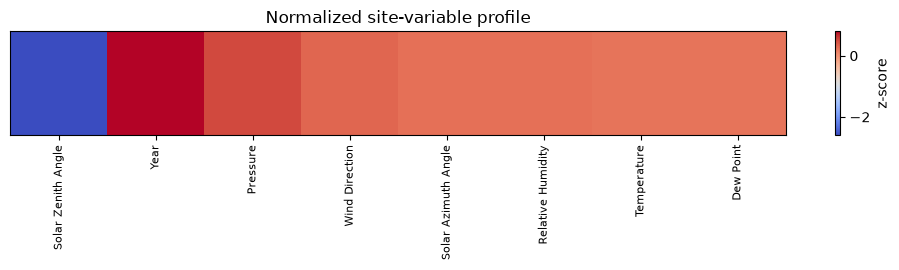

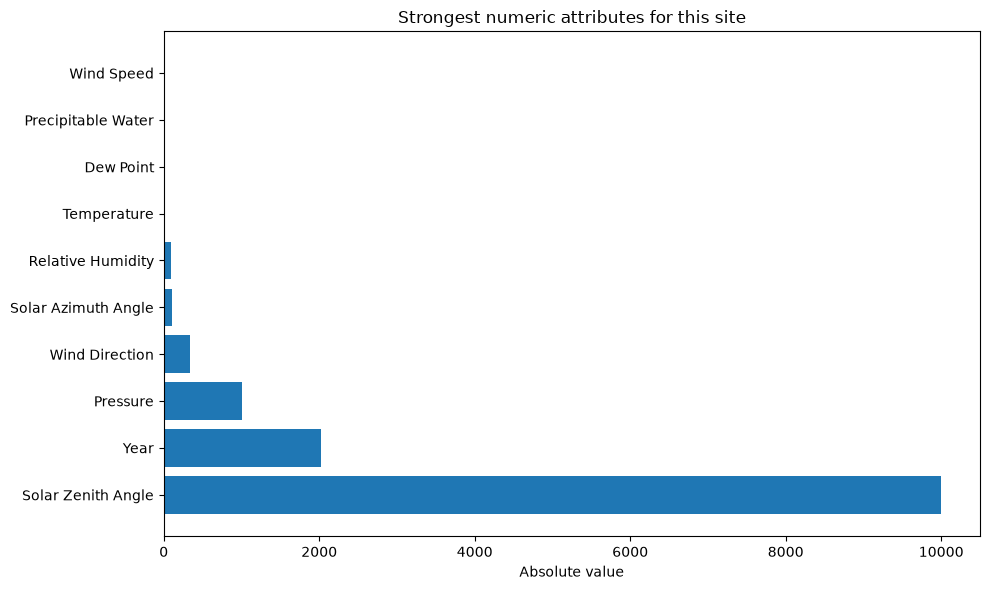


Relevant field summary:


,count,mean,std,min,25%,50%,75%,max
Temperature,8760.0,24.869589,5.553051,6.40,21.600,26.40,28.80,35.20
Pressure,8760.0,1006.099429,6.131307,987.00,1001.000,1007.00,1011.00,1019.00
GHI,8760.0,204.626256,279.229938,0.00,0.000,3.50,414.00,946.00
DNI,8760.0,150.272603,221.292982,0.00,0.000,0.00,288.00,900.00
DHI,8760.0,107.026142,142.612618,0.00,0.000,3.50,210.00,524.00
Clearsky GHI,8760.0,248.828995,322.027527,0.00,0.000,4.00,527.25,989.00
Clearsky DNI,8760.0,229.906963,282.947927,0.00,0.000,2.00,486.00,900.00
Clearsky DHI,8760.0,92.943721,119.455801,0.00,0.000,4.00,172.00,529.00
Relative Humidity,8760.0,80.241818,17.838749,20.03,69.115,84.03,95.81,100.00
Wind Speed,8760.0,1.726986,0.880158,0.10,1.100,1.50,2.20,7.50


In [4]:
# This file has only one row, so conventional outlier/correlation/monthly analyses are not meaningful.
# Instead, we profile the site-level values and highlight the strongest numeric attributes.

numeric_cols = df.select_dtypes(include="number").columns.tolist()
if numeric_cols:
    site_numeric = df[numeric_cols].iloc[0].dropna()
    if not site_numeric.empty:
        site_profile = pd.DataFrame({
            "value": site_numeric,
            "abs_value": site_numeric.abs(),
        }).sort_values("abs_value", ascending=False)

        print("Site-level numeric profile:")
        display(site_profile.head(12))

        top_cols = site_profile.head(8).index.tolist()
        values = site_numeric[top_cols]
        if values.std(ddof=0) > 0:
            z_scores = (values - values.mean()) / values.std(ddof=0)
        else:
            z_scores = pd.Series(0.0, index=values.index)

        fig, ax = plt.subplots(figsize=(10, 2.8))
        im = ax.imshow(z_scores.to_numpy().reshape(1, -1), cmap="coolwarm", aspect="auto")
        ax.set_xticks(range(len(z_scores.index)))
        ax.set_xticklabels(z_scores.index, rotation=90, fontsize=8)
        ax.set_yticks([])
        ax.set_title("Normalized site-variable profile")
        fig.colorbar(im, ax=ax, label="z-score")
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(10, 6))
        top = site_profile.head(10)
        ax.barh(top.index, top["abs_value"], color="#1f77b4")
        ax.set_title("Strongest numeric attributes for this site")
        ax.set_xlabel("Absolute value")
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric values available for site profiling.")
else:
    print("No numeric columns available for site profiling.")

# Compact summary of the most relevant solar/site variables.
solar_cols = [
    c for c in [
        "Latitude", "Longitude", "Elevation", "Temperature", "Pressure",
        "GHI", "DNI", "DHI", "Clearsky GHI", "Clearsky DNI", "Clearsky DHI",
        "Relative Humidity", "Wind Speed", "Surface Albedo"
    ]
    if c in df.columns
]
if solar_cols:
    summary = df[solar_cols].copy()
    print("\nRelevant field summary:")
    display(summary.describe(include="all").T)
else:
    print("\nNo recognisable solar/site columns found.")


## EDA Findings

- The dataset contains 8,760 rows and 2,034 columns, representing one full year of hourly NSRDB data for Bangladesh in 2018.
- The dataset includes temporal variables such as Year, Month, Day, Hour, and Minute, along with weather, solar radiation, atmospheric, and spectral measurements.
- The main solar variables such as GHI, DNI, and DHI contain complete hourly observations, while some specialized fields such as Panel Tilt and Panel Azimuth Angle contain missing values.
- The dataset contains no duplicate rows, indicating that the hourly records are unique.
- The average temperature is approximately 24.87°C, while the average GHI, DNI, and DHI are approximately 204.63, 150.27, and 107.03 respectively.
- The dataset has very high dimensionality because it contains hundreds of spectral wavelength features in addition to the core meteorological and solar variables.
- Overall, the 2018 NSRDB dataset provides a detailed hourly representation of solar and weather conditions and is suitable for solar-resource analysis, temporal analysis, and feature engineering.